Introduction
### Data Science Intern – Round 0 Assignment
# Trader Performance vs Market Sentiment

In [42]:
#PART-1 Data preparation
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

sentiment.head(10)
trades.head(10)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,02-12-2024 22:50,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,1.730000e+12
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,02-12-2024 22:50,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,1.730000e+12
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,02-12-2024 22:50,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,1.730000e+12
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,02-12-2024 22:50,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,1.730000e+12
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,02-12-2024 22:50,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,1.730000e+12


In [2]:
sentiment.shape
trades.shape

(9322, 16)

In [3]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9322 entries, 0 to 9321
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           9322 non-null   object 
 1   Coin              9322 non-null   object 
 2   Execution Price   9322 non-null   float64
 3   Size Tokens       9322 non-null   float64
 4   Size USD          9322 non-null   float64
 5   Side              9322 non-null   object 
 6   Timestamp IST     9322 non-null   object 
 7   Start Position    9321 non-null   float64
 8

In [4]:
sentiment.isna().sum()
trades.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,1
Direction,1
Closed PnL,1


In [5]:
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

## Data Quality Check
#Sentiment dataset has 2644 rows and 4 columns
#Trader dataset has 211224 rows and 16 columns
#No missing values
#No duplicates found


In [6]:
sentiment.columns
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [7]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [8]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='mixed', dayfirst=True, errors='coerce')
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9322 entries, 0 to 9321
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           9322 non-null   object        
 1   Coin              9322 non-null   object        
 2   Execution Price   9322 non-null   float64       
 3   Size Tokens       9322 non-null   float64       
 4   Size USD          9322 non-null   float64       
 5   Side              9322 non-null   object        
 6   Timestamp IST     9321 non-null   datetime64[ns]
 7   Start Position    9321 non-null   float64       
 8   Direction         9321 non-null   object        
 9   Closed PnL        9321 non-null   float64       
 10  Transaction Hash  9321 non-null   object        
 11  Order ID          9321 non-null   float64       
 12  Crossed           9321 non-null   object        
 13  Fee               9321 non-null   float64       
 14  Trade ID          9321 n

In [9]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'].dt.date)
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9322 entries, 0 to 9321
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           9322 non-null   object        
 1   Coin              9322 non-null   object        
 2   Execution Price   9322 non-null   float64       
 3   Size Tokens       9322 non-null   float64       
 4   Size USD          9322 non-null   float64       
 5   Side              9322 non-null   object        
 6   Timestamp IST     9321 non-null   datetime64[ns]
 7   Start Position    9321 non-null   float64       
 8   Direction         9321 non-null   object        
 9   Closed PnL        9321 non-null   float64       
 10  Transaction Hash  9321 non-null   object        
 11  Order ID          9321 non-null   float64       
 12  Crossed           9321 non-null   object        
 13  Fee               9321 non-null   float64       
 14  Trade ID          9321 n

#Merge both datasets

In [10]:
trades['date'] = pd.to_datetime(trades['date'])
merged = trades.merge(sentiment[['date','classification']],on='date', how='left')
merged.head(10)
merged.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9322 entries, 0 to 9321
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           9322 non-null   object        
 1   Coin              9322 non-null   object        
 2   Execution Price   9322 non-null   float64       
 3   Size Tokens       9322 non-null   float64       
 4   Size USD          9322 non-null   float64       
 5   Side              9322 non-null   object        
 6   Timestamp IST     9321 non-null   datetime64[ns]
 7   Start Position    9321 non-null   float64       
 8   Direction         9321 non-null   object        
 9   Closed PnL        9321 non-null   float64       
 10  Transaction Hash  9321 non-null   object        
 11  Order ID          9321 non-null   float64       
 12  Crossed           9321 non-null   object        
 13  Fee               9321 non-null   float64       
 14  Trade ID          9321 n

In [11]:
merged['classification'].isna().sum()

np.int64(7)

In [12]:
daily_pnl=(merged
           .groupby(['Account','date'])['Closed PnL']
           .sum()
           .reset_index()
)

daily_pnl.head()

,Account,date,Closed PnL
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-09,0.000000
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-12,0.000000
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-15,0.000000
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-19,0.000000
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,2025-02-14,194499.072534


In [13]:
merged['win']=merged['Closed PnL']>0

In [14]:
win_rate = (
    merged
    .groupby('Account')['win']
    .mean()
    .reset_index()
)

win_rate.head()

,Account,win
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,0.384909
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.306294
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.408526


In [15]:
daily_trades=(
    merged
    .groupby(['Account','date'])
    .size()
    .reset_index(name='trade_count')
)

daily_trades.head()

,Account,date,trade_count
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-09,42
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-12,89
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-15,28
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-19,64
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,2025-02-14,464


In [16]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,198.456185
Extreme Greed,33.592341
Fear,80.628446
Greed,90.039623
Neutral,174.831053


In [17]:
merged.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.315301
Extreme Greed,0.165625
Fear,0.389221
Greed,0.206687
Neutral,0.532822


In [18]:
merged.groupby('classification').size()

,0
classification,
Extreme Fear,647
Extreme Greed,640
Fear,6197
Greed,658
Neutral,1173


In [ ]:

merged.groupby('classification')['Closed PnL'].std()

,Closed PnL
classification,
Extreme Fear,2508.465987
Extreme Greed,175.430976
Fear,666.291725
Greed,643.800233
Neutral,669.799159


In [ ]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,6539.688454
Extreme Greed,3061.835375
Fear,33962.038979
Greed,2198.430030
Neutral,9494.057707


##Traders significantly increase position sizes during Fear regimes (average $33,962), suggesting aggressive dip-buying behavior. However, Extreme Fear periods show the highest PnL volatility (std = 2,508), indicating unstable and high-risk outcomes.

In [ ]:
merged.groupby('classification')['Size USD'].median()

,Size USD
classification,
Extreme Fear,876.770
Extreme Greed,1082.555
Fear,1006.460
Greed,580.265
Neutral,852.790


In [19]:
merged.groupby(['classification','Side']).size()

classification  Side
Extreme Fear    BUY      404
                SELL     243
Extreme Greed   BUY      323
                SELL     317
Fear            BUY     3202
                SELL    2995
Greed           BUY      154
                SELL     504
Neutral         BUY      527
                SELL     646
dtype: int64

##True leverage data was unavailable; therefore, position size relative to trader baseline was used as a leverage proxy.

In [43]:

account_avg_size = merged.groupby('Account')['Size USD'].mean()

merged = merged.merge(account_avg_size.rename('avg_size'), on='Account')

merged['proxy_leverage'] = merged['Size USD'] / merged['avg_size']

In [44]:
merged.groupby('classification')['proxy_leverage'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,647.0,0.751030,2.313854,0.000026,0.019760,0.163139,0.425465,27.826606
Extreme Greed,640.0,0.805674,1.724804,0.000034,0.040716,0.160811,0.693833,13.642844
Fear,6197.0,1.167050,4.244950,0.000005,0.030546,0.141170,0.652626,114.528842
Greed,658.0,0.944740,2.080356,0.000112,0.068795,0.258623,0.622211,18.074036
Neutral,1173.0,0.362314,1.015647,0.000020,0.003714,0.065547,0.163847,8.828823


In [21]:
#Segment by Trade Frequency
trade_counts = merged.groupby('Account').size().reset_index(name='trade_count')
trade_counts.head()

,Account,trade_count
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,7329
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563


In [22]:
threshold = trade_counts['trade_count'].median()
threshold

1430.0

In [23]:
trade_counts['frequency_segment'] = trade_counts['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

trade_counts.head()

,Account,trade_count,frequency_segment
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,7329,Frequent
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,Infrequent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,Infrequent


In [24]:
#Segment by Profitability
win_rate = (
    merged
    .assign(win = merged['Closed PnL'] > 0)
    .groupby('Account')['win']
    .mean()
    .reset_index()
)

win_rate.head()

,Account,win
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,0.384909
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.306294
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.408526


In [25]:
win_rate['profit_segment'] = win_rate['win'].apply(
    lambda x: 'Consistent' if x > 0.5 else 'Inconsistent'
)

In [26]:
segments = trade_counts.merge(win_rate[['Account','profit_segment']], on='Account')
segments.head()

,Account,trade_count,frequency_segment,profit_segment
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,7329,Frequent,Inconsistent
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,Infrequent,Inconsistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,Infrequent,Inconsistent


In [27]:
segments = trade_counts.merge(win_rate[['Account','profit_segment']], on='Account')
segments.head()

,Account,trade_count,frequency_segment,profit_segment
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,7329,Frequent,Inconsistent
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,Infrequent,Inconsistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,Infrequent,Inconsistent


In [28]:
merged = merged.merge(segments[['Account', 'frequency_segment', 'profit_segment']], on='Account', how='left')
merged.groupby(['classification','frequency_segment','profit_segment'])['Closed PnL'].mean()

classification  frequency_segment  profit_segment
Extreme Fear    Frequent           Inconsistent     -205.554395
                Infrequent         Inconsistent      662.867018
Extreme Greed   Frequent           Inconsistent        0.000000
                Infrequent         Inconsistent       51.556591
Fear            Frequent           Inconsistent       61.494027
                Infrequent         Inconsistent      275.530118
Greed           Infrequent         Inconsistent       90.039623
Neutral         Frequent           Inconsistent      187.816777
                Infrequent         Inconsistent      -79.415763
Name: Closed PnL, dtype: float64

In [29]:
win_rate['win'].describe()

,win
count,3.000000
mean,0.366576
std,0.053525
min,0.306294
25%,0.345601
50%,0.384909
75%,0.396718
max,0.408526


In [30]:
win_rate.sort_values('win', ascending=False).head(10)

,Account,win,profit_segment
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.408526,Inconsistent
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,0.384909,Inconsistent
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.306294,Inconsistent


In [31]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

median_pnl = total_pnl['Closed PnL'].median()

total_pnl['profit_segment'] = total_pnl['Closed PnL'].apply(
    lambda x: 'Profitable' if x > median_pnl else 'Less Profitable'
)

In [32]:
merged.groupby(['classification','frequency_segment','profit_segment'])['Closed PnL'].mean()

classification  frequency_segment  profit_segment
Extreme Fear    Frequent           Inconsistent     -205.554395
                Infrequent         Inconsistent      662.867018
Extreme Greed   Frequent           Inconsistent        0.000000
                Infrequent         Inconsistent       51.556591
Fear            Frequent           Inconsistent       61.494027
                Infrequent         Inconsistent      275.530118
Greed           Infrequent         Inconsistent       90.039623
Neutral         Frequent           Inconsistent      187.816777
                Infrequent         Inconsistent      -79.415763
Name: Closed PnL, dtype: float64

In [33]:
total_pnl = (
    merged
    .groupby('Account')['Closed PnL']
    .sum()
    .reset_index()
)

total_pnl.head()

,Account,Closed PnL
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,485492.498294
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,403011.504159
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,67845.619531


In [34]:
median_pnl = total_pnl['Closed PnL'].median()
median_pnl

403011.504159

In [35]:
total_pnl['profit_segment'] = total_pnl['Closed PnL'].apply(
    lambda x: 'Profitable' if x > median_pnl else 'Less Profitable'
)

total_pnl.head()

,Account,Closed PnL,profit_segment
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,485492.498294,Profitable
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,403011.504159,Less Profitable
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,67845.619531,Less Profitable


In [36]:
merged = merged.drop(columns=['profit_segment'], errors='ignore')

merged = merged.merge(
    total_pnl[['Account','profit_segment']],
    on='Account',
    how='left'
)

In [37]:
merged.groupby(
    ['classification','frequency_segment','profit_segment']
)['Closed PnL'].mean()

classification  frequency_segment  profit_segment 
Extreme Fear    Frequent           Profitable        -205.554395
                Infrequent         Less Profitable    662.867018
Extreme Greed   Frequent           Profitable           0.000000
                Infrequent         Less Profitable     51.556591
Fear            Frequent           Profitable          61.494027
                Infrequent         Less Profitable    275.530118
Greed           Infrequent         Less Profitable     90.039623
Neutral         Frequent           Profitable         187.816777
                Infrequent         Less Profitable    -79.415763
Name: Closed PnL, dtype: float64

##Heatmap visualization

In [38]:
heatmap_data = (
    merged
    .groupby(['classification','frequency_segment'])['Closed PnL']
    .mean()
    .unstack()
)

heatmap_data

frequency_segment,Frequent,Infrequent
classification,,
Extreme Fear,-205.554395,662.867018
Extreme Greed,0.000000,51.556591
Fear,61.494027,275.530118
Greed,NaN,90.039623
Neutral,187.816777,-79.415763


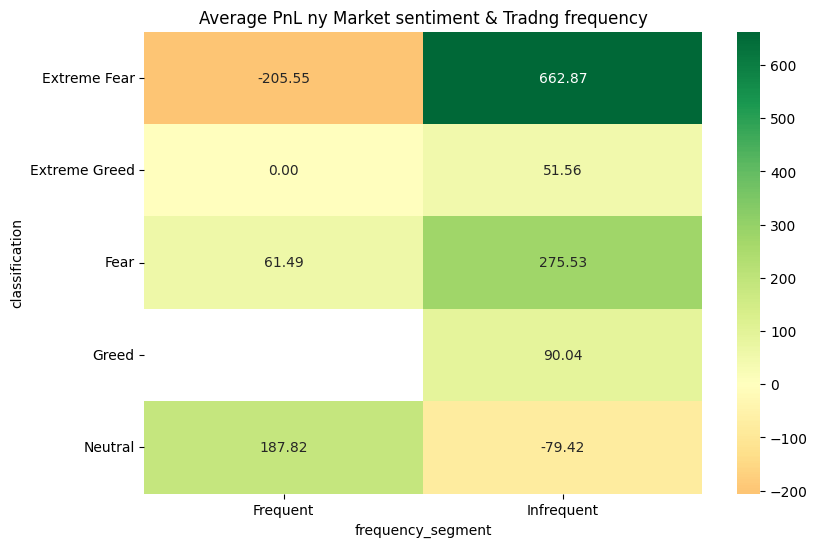

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
sns.heatmap(heatmap_data,annot=True,fmt=".2f",cmap='RdYlGn',center=0)
plt.title("Average PnL ny Market sentiment & Tradng frequency")
plt.show()

##Green = profitable

##Red = losing

##Darker = stronger effect

In [40]:
from scipy.stats import ttest_ind

extreme_fear = merged[merged['classification']=='Extreme Fear']

frequent = extreme_fear[extreme_fear['frequency_segment']=='Frequent']['Closed PnL']
infrequent = extreme_fear[extreme_fear['frequency_segment']=='Infrequent']['Closed PnL']

t_stat,p_value = ttest_ind(frequent,infrequent,equal_var=False)
print("T-stat:",t_stat)
print("P-value:",p_value)

T-stat: -4.391169062720916
P-value: 1.3417579314720356e-05


In [41]:
for sentiment in merged['classification'].unique():
    subset = merged[merged['classification']==sentiment]
    frequent = subset[subset['frequency_segment']=='Frequent']['Closed PnL']
    infrequent = subset[subset['frequency_segment']=='Infrequent']['Closed PnL']

    if len(frequent)>5 and len(infrequent)>5:
      t_stat,p_value = ttest_ind(frequent,infrequent,equal_var=False)
      print(f"{sentiment}->p_value:{p_value:.4f}")

Extreme Greed->p_value:0.0000
Extreme Fear->p_value:0.0000
Fear->p_value:0.0000
Neutral->p_value:0.0003


#Drawdown proxy

In [45]:
worst_loss = (
    merged
    .groupby('classification')['Closed PnL']
    .min()
)

worst_loss

,Closed PnL
classification,
Extreme Fear,-29370.119800
Extreme Greed,0.000000
Fear,-6123.212194
Greed,0.000000
Neutral,-3852.372590


In [46]:
avg_loss = (
    merged[merged['Closed PnL'] < 0]
    .groupby('classification')['Closed PnL']
    .mean()
)

avg_loss

,Closed PnL
classification,
Extreme Fear,-727.896229
Fear,-187.309731
Neutral,-905.339694


In [47]:
loss_rate = (
    merged
    .assign(loss = merged['Closed PnL'] < 0)
    .groupby('classification')['loss']
    .mean()
)

loss_rate

,loss
classification,
Extreme Fear,0.225657
Extreme Greed,0.000000
Fear,0.062450
Greed,0.000000
Neutral,0.004263


##Predict next day trade profitability bucket

In [50]:
# Calculate the next day's PnL for each account
daily_pnl['next_day_pnl'] = daily_pnl.groupby('Account')['Closed PnL'].shift(-1)

# Define next_day_profit as 1 if next_day_pnl is positive, 0 otherwise
daily_pnl['next_day_profit'] = (daily_pnl['next_day_pnl'] > 0).astype(int)

# Drop rows where next_day_pnl (and thus next_day_profit) is NaN
# This happens for the last day of trading for each account, as there's no 'next day'
daily_pnl = daily_pnl.dropna(subset=['next_day_pnl'])

In [51]:
# Sort properly
merged = merged.sort_values(['Account','date'])

# Daily PnL per trader
daily_pnl = (
    merged.groupby(['Account','date'])['Closed PnL']
    .sum()
    .reset_index()
)

# Create next-day PnL
daily_pnl['next_day_pnl'] = (
    daily_pnl.groupby('Account')['Closed PnL']
    .shift(-1)
)

# Create classification label
daily_pnl['next_day_profitable'] = (daily_pnl['next_day_pnl'] > 0).astype(int)

In [52]:
daily_pnl['rolling_vol'] = (
    daily_pnl.groupby('Account')['Closed PnL']
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Ensure 'date' column in daily_pnl is datetime objects before merging
daily_pnl['date'] = pd.to_datetime(daily_pnl['date'])

# Explicitly ensure sentiment['date'] is also datetime type before merging
sentiment_for_merge = sentiment[['date', 'classification']].copy()
sentiment_for_merge['date'] = pd.to_datetime(sentiment_for_merge['date'])

# Merge classification from sentiment into daily_pnl
daily_pnl = daily_pnl.merge(sentiment_for_merge, on='date', how='left')

# Drop rows with any NaN values that might be present after merging sentiment or from rolling_vol
# Specifically dropping rows where 'classification' is NaN, as these rows won't contribute meaningful sentiment info
# Also ensure 'rolling_vol' (first few rows per group) and 'next_day_pnl' (last day per group) are not NaN
daily_pnl = daily_pnl.dropna(subset=['next_day_pnl', 'rolling_vol', 'classification'])

# Convert sentiment to numeric
daily_pnl = pd.get_dummies(daily_pnl, columns=['classification'], drop_first=True)

# Define features (X) and target (y)
# Exclude 'Account' (identifier), 'Closed PnL' (potential data leakage for prediction),
# 'next_day_pnl' (direct target value), 'next_day_profitable' (the target), and 'date' (already used for merge)
X = daily_pnl.drop(columns=['Account', 'Closed PnL', 'next_day_pnl','next_day_profitable','date'])
y = daily_pnl['next_day_profitable']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions and evaluate
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.41      0.78      0.54         9
           1       0.00      0.00      0.00        10

    accuracy                           0.37        19
   macro avg       0.21      0.39      0.27        19
weighted avg       0.20      0.37      0.26        19



In [60]:
#Predict next day volatility
daily_pnl['next_day_vol'] = (
    daily_pnl.groupby('Account')['Closed PnL']
    .shift(-1).rolling(5).std()
)

In [64]:
#Clustring traders into behavioral archtypes
trader_features = merged.groupby('Account').agg({
    'Closed PnL': ['mean', 'std'],
    'Size USD': 'mean',
    'win': 'mean',
    'date': 'count'
}).reset_index()

trader_features.columns = [
    'Account',
    'avg_pnl',
    'pnl_volatility',
    'avg_trade_size',
    'win_rate',
    'total_trades'
]

In [66]:
#lonf/short ratio
long_short = (
    merged.groupby(['Account','Side'])
    .size()
    .unstack(fill_value=0)
)

long_short['long_ratio'] = long_short['BUY'] / (
    long_short['BUY'] + long_short['SELL']
)

trader_features = trader_features.merge(
    long_short[['long_ratio']],
    left_on='Account',
    right_index=True
)